# Cost-aware simulation-based inference: Replication of Bernoulli SIR case study

Author: Hans Olischläger

Recently, an interesting paper has come out to reduce the simulation cost in simulation-based inference workflows using augmented priors and importance weights.

*Bharti, A., Huang, D., Kaski, S., & Briol, F.-X. (2025). Cost-aware simulation-based inference (No. arXiv:2410.07930). arXiv. https://doi.org/10.48550/arXiv.2410.07930*

This notebook reproduces an example from the paper using BayesFlow: Bernoulli SIR.

In [1]:
import os
import pickle
import time
from functools import partial

os.environ["KERAS_BACKEND"] = "jax"

import bayesflow as bf
import keras
import numpy as np
import matplotlib.pyplot as plt

INFO:bayesflow:Using backend 'jax'


In [2]:
def prior_func(beta_low=0.1, beta_high=1.0,
                 gamma_low=0.1, gamma_high=1.0,
                 p_low=0.1, p_high=1.0):
    return dict(
        beta=np.random.uniform(beta_low, beta_high),
        gamma=np.random.uniform(gamma_low, gamma_high),
        p=np.random.uniform(p_low, p_high),
    )
    
prior_func()

{'beta': 0.4148671772018724,
 'gamma': 0.601001546509078,
 'p': 0.9696894127332211}

In [3]:
def simulate_bern_sir(beta, gamma, p, N=100, num_bins=10):
    """
    Gillespie simulation of a Bernoulli SIR epidemic on a random network.
    Uses incremental updates of contact counts to avoid repeated full-matrix computations.

    Parameters
    ----------
    beta : float
        Transmission rate per contact.
    gamma : float
        Recovery rate per infected individual.
    p : float
        Probability of edge between any two nodes.
    N : int, optional
        Number of nodes (default 100).
    num_bins : int, optional
        Number of bins for recovery-time histogram (default 10).

    Returns
    -------
    dict
        "removals_per_bin": np.ndarray, histogram of recovery times
        "total_removals": int, total number recovered
        "duration": float, time of last recovery
        "time": elapsed time for the simulation
    """
    t0 = time.time()
    # Build random adjacency (Erdős–Rényi) and remove self-loops
    adj = np.random.binomial(1, p, size=(N, N))
    np.fill_diagonal(adj, 0)

    # State vector: 0 = S, 1 = I, 2 = R
    state = np.zeros(N, dtype=int)
    state[0] = 1  # seed one infection

    # Initial contact counts (# infected neighbors per node)
    contact_counts = adj.dot((state == 1).astype(int))

    # Time and recovery records
    t = 0.0
    recovery_times = []
    total_recovered = 0

    # Gillespie loop
    while np.any(state == 1):
        num_inf = np.sum(state == 1)
        total_contacts = contact_counts.sum()

        # Sample time to next event
        rate = gamma * num_inf + beta * total_contacts
        t += np.random.exponential(scale=1.0 / rate)

        # Determine event
        if total_contacts > 0 and np.random.rand() < (beta * total_contacts) / rate:
            # Infection: choose infector weighted by its contact count
            probs = contact_counts / total_contacts
            infector = np.random.choice(N, p=probs)
            neighbors = np.nonzero(adj[infector])[0]
            if neighbors.size:
                target = np.random.choice(neighbors)
                if state[target] == 0:
                    state[target] = 1
                    # Update contact counts incrementally
                    contact_counts += adj[:, target]
        else:
            # Recovery: choose one infected to recover
            infected_idx = np.nonzero(state == 1)[0]
            recovering = np.random.choice(infected_idx)
            state[recovering] = 2
            total_recovered += 1
            recovery_times.append(t)
            # Decrement contact counts
            contact_counts -= adj[:, recovering]

    # Summarize
    duration = recovery_times[-1] if recovery_times else 0.0
    hist_range = (0, duration) if duration > 0 else (0, num_bins)
    removals_per_bin, _ = np.histogram(recovery_times, bins=num_bins, range=hist_range)

    t1 = time.time()

    return {
        "removals_per_bin": removals_per_bin,
        "total_removals": total_recovered,
        "duration": duration,
        "time": t1-t0,
    }

simulate_bern_sir(**prior_func())

{'removals_per_bin': array([20, 20, 14, 16,  8,  8,  5,  6,  1,  2]),
 'total_removals': 100,
 'duration': 6.057643489392802,
 'time': 0.2865579128265381}

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.gridspec import GridSpec
from IPython.display import HTML


def simulate_trajectory_full(beta, gamma, p, N=50):
    # Build random adjacency
    adj = np.random.binomial(1, p, size=(N, N))
    np.fill_diagonal(adj, 0)
    neighbors = [np.where(adj[i])[0] for i in range(N)]
    G = nx.from_numpy_array(adj)

    # States: 0=S, 1=I, 2=R
    state = np.zeros(N, dtype=int)
    state[0] = 1

    t = 0.0
    times = [t]
    states = [state.copy()]
    recovery_times = []

    # Keep running while there's at least one I
    while np.any(state == 1):
        inf_vec = (state == 1).astype(int)
        contact_counts = adj.dot(inf_vec)
        total_contacts = contact_counts.sum()
        num_inf = inf_vec.sum()

        rate = gamma * num_inf + beta * total_contacts
        t += np.random.exponential(1.0 / rate)

        if total_contacts > 0 and np.random.rand() < (beta * total_contacts) / rate:
            # Infection event
            probs = contact_counts / total_contacts
            infector = np.random.choice(N, p=probs)
            nbrs = neighbors[infector]
            if nbrs.size:
                tgt = np.random.choice(nbrs)
                if state[tgt] == 0:
                    state[tgt] = 1
                    # update contact counts incrementally
                    contact_counts += adj[:, tgt]
        else:
            # Recovery event (only called when state==1 is non‐empty)
            inf_list = np.where(state == 1)[0]
            rec = np.random.choice(inf_list)
            state[rec] = 2
            recovery_times.append(t)
            # update contact counts incrementally
            contact_counts -= adj[:, rec]

        times.append(t)
        states.append(state.copy())

    return G, np.array(times), states, np.array(recovery_times)


np.random.seed(0)
beta, gamma, p = 0.5, 0.3, 0.1
G, times, states, recovery_times = simulate_trajectory_full(beta, gamma, p, N=50)

# histogram bins
num_bins = 10
bins = np.linspace(0, times[-1], num_bins+1)
max_count = len(recovery_times)  # for y-axis limit

# subsample frames
max_frames = 50
indices = np.linspace(0, len(states)-1, min(max_frames, len(states)), dtype=int)

In [5]:
import matplotlib
matplotlib.rcParams.update({"font.size": 15})

In [6]:
# Create a 1×2 grid with width_ratios so the histogram is much narrower
fig = plt.figure(figsize=(12, 5))
gs = GridSpec(1, 2, figure=fig, width_ratios=[1.5, 1], wspace=0.1)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

pos = nx.spring_layout(G, seed=0)

def tweak_histogram(ax):
    ax.set_xlabel("t")
    ax.set_xlim(0, times[-1])
    ax.set_ylim(0, max_count/3)
    ax.set_xticks([0, 5, 10, 15])
    ax.set_yticks([0, 5, 10, 15])
    ax.spines.left.set_position(("outward", 10))
    ax.spines.bottom.set_position(("outward", 10))
    ax.spines.right.set_visible(False)
    ax.spines.top.set_visible(False)
    ax.yaxis.set_ticks_position("left")
    ax.xaxis.set_ticks_position("bottom")
    ax.set_title("Removals")

def update(frame_idx):
    idx = indices[frame_idx]
    t_now = times[idx]

    # Left: network
    ax1.clear()
    cols = ["C2" if s==0 else "C1" if s==1 else "C0" for s in states[idx]]
    nx.draw(G, pos,
            node_color=cols,
            edge_color="grey",
            with_labels=False,
            node_size=50,
            ax=ax1)
    ax1.set_title(rf"$\beta={beta}$ $\gamma={beta}$ $p={beta}$ \n $t = {t_now:.2f}$", ha="left", loc="left")
    ax1.axis("off")

    # Right: small histogram
    ax2.clear()
    cnts, _ = np.histogram(recovery_times[recovery_times <= t_now], bins=bins)
    ax2.bar(
        bins[:-1], cnts,
        width=(bins[1] - bins[0]),
        align="edge",
        color="C0",
        edgecolor="black"
    )
    tweak_histogram(ax2)


ani = FuncAnimation(fig, update,
                    frames=len(indices),
                    interval=150,
                    repeat=False)

fig.tight_layout(pad=0.1)
plt.close(fig)
HTML(ani.to_jshtml())

/tmp/ipykernel_2230517/4098062153.py:58: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(pad=0.1)
INFO:matplotlib.animation:Animation.save using <class 'matplotlib.animation.HTMLWriter'>


# Simulating a small batch of training data

We now glue the prior and likelihood together to obtain a simulator of the full data generating process.

In [7]:
prior = bf.make_simulator([prior_func])
simulator = bf.make_simulator([prior_func, simulate_bern_sir])
simulator.sample(3)

{'beta': array([[0.85005959],
        [0.89911964],
        [0.58058908]]),
 'gamma': array([[0.20708781],
        [0.87228435],
        [0.97386105]]),
 'p': array([[0.96817595],
        [0.93158384],
        [0.12357729]]),
 'removals_per_bin': array([[29, 19, 17, 12,  8,  3,  3,  3,  2,  4],
        [36, 26, 18, 10,  5,  1,  2,  1,  0,  1],
        [ 4, 35, 26, 15, 10,  2,  2,  2,  0,  1]]),
 'total_removals': array([[100],
        [100],
        [ 97]]),
 'duration': array([[18.86620699],
        [ 5.49652572],
        [ 8.38643106]]),
 'time': array([[1.80592847],
        [0.33015013],
        [0.03159356]])}

Let's get a few simulations to use later:
* a tiny training batch of simulations
* a medium sized batch of simulations as held out validation data
* a huge set of simulations to train a reference solution

In [8]:
def load_or_simulate(sim_fn, path, *args, **kwargs):
    """
    Load simulations from `path` if it exists, otherwise call sim_fn(*args, **kwargs),
    pickle the result to `path`, and return it.
    """
    if os.path.exists(path):
        with open(path, "rb") as f:
            sims = pickle.load(f)
        num_samples = sims["beta"].shape[0]
        print(f"Loaded {num_samples} sims from cache: {path}")
    else:
        sims = sim_fn(*args, **kwargs)
        with open(path, "wb") as f:
            pickle.dump(sims, f)
        num_samples = sims["beta"].shape[0]
        print(f"Simulated {num_samples} runs and saved to cache: {path}")
    return sims

In [9]:
train_path_small = "train_sims_small.pkl"
val_path   = "val_sims.pkl"
train_path_large = "train_sims_large.pkl"

train_sims_small = load_or_simulate(simulator.sample, train_path_small, 200)
val_sims   = load_or_simulate(simulator.sample, val_path, 1000)
val_sims = {k:v[:100] for k,v in val_sims.items()}
train_sims_large = load_or_simulate(simulator.sample, train_path_large, 50_000)

Loaded 200 sims from cache: train_sims_small.pkl
Loaded 1000 sims from cache: val_sims.pkl
Loaded 50000 sims from cache: train_sims_large.pkl


# Fit cost model

In the simulator we already keep track of the simulation duration. We will subsequently treat that as a cost that we seek to reduce. With the simulated samples we can fit a Gaussian Process to make the expected cost (duration) available as a function of parameters.

In [10]:
# currently not resolvable with numpy 2.x, so I believe the notebook does not run
# in a fresh environment with current bayesflow deps (including numpy>=2.5.1)
import GPy
GPy.plotting.change_plotting_library("matplotlib")

In [11]:
par_names = ["beta", "gamma", "p"]

In [12]:
def fit_gp(sims, feature_names, target_name):
    X = np.concatenate([value for key, value in sims.items() if key in feature_names], axis=1)
    Y = sims[target_name]
    kernel = GPy.kern.RBF(input_dim=len(feature_names), variance=1., lengthscale=1.)
    m = GPy.models.GPRegression(X,Y,kernel)
    m.optimize(messages=True)
    return m

In [13]:
%%time
cost_model = fit_gp(train_sims_small, par_names, "time")

INFO:GP:initializing Y
INFO:GP:initializing inference method
INFO:GP:adding kernel and likelihood as parameters


Running L-BFGS-B (Scipy implementation) Code:
  runtime   i      f              |g|        
    00s03  0005  -1.676951e+02   7.153412e+03 
    00s14  0017  -1.891457e+02   1.392661e+00 
    00s25  0026  -1.892252e+02   9.005477e-08 
Runtime:     00s25
Optimization status: Converged

CPU times: user 672 ms, sys: 2.19 s, total: 2.86 s
Wall time: 275 ms


Great! Our Gaussian Process model for the cost converged in less than a second and now we can write a litte wrapper around it to use it inside a BayesFlow simulator.

In [14]:
def expected_cost(batch_shape, beta, gamma, p, cost_model):
    X = np.concatenate([beta, gamma, p], axis=1)
    mean = cost_model.predict(X)[0][:,0]
    epsilon = 1e-1
    mean = np.maximum(epsilon, mean)
    return dict(cost=mean)

We also define a penalty based on that cost - it will become important later when we use it as a factor to downweight the occurance of the respective sample. 

In [15]:
def calculate_penalty(cost):
    # j = np.random.randint(0,4)
    j = 1
    penalty = cost**j
    # penalty = np.maximum(1, penalty)
    return dict(penalty=penalty, j=j)

Glueing both together, we define a simulator using these batched functions to compute cost and penalty. We can conviniently append that to the prior too. 

In [16]:
cost_simulator = bf.simulators.LambdaSimulator(partial(expected_cost, cost_model=cost_model), is_batched=True)
penalty_simulator = bf.simulators.LambdaSimulator(calculate_penalty)

prior_with_cost_penalty = bf.simulators.SequentialSimulator([prior, cost_simulator, penalty_simulator])

We will later be interested in varying j for different scalings of the penalty. To make that convenient we write a little function that produces the corresponding simulator given a calculate_penalty function.

In [17]:
def make_prior_with_cost_penalty(penalty_func):
    return bf.make_simulator([prior, cost_simulator, penalty_func])

In [18]:
prior_with_cost_penalty = make_prior_with_cost_penalty(calculate_penalty)
prior_with_cost_penalty.sample(3)

{'beta': array([[0.89609381],
        [0.85768207],
        [0.60731669]]),
 'gamma': array([[0.41959136],
        [0.13739832],
        [0.18050948]]),
 'p': array([[0.66056903],
        [0.84249817],
        [0.22896732]]),
 'cost': array([[0.49670649],
        [1.90953809],
        [0.32062251]]),
 'penalty': array([[0.49670649],
        [1.90953809],
        [0.32062251]]),
 'j': array([[1],
        [1],
        [1]])}

# Rejection sampling

As promised, we will do rejection sampling based on the penalty value. The `prior_with_cost_penalty` simulator will provide the proposal distribution and penalty values.

In [19]:
def reject_based_on_penalty(
    samples: dict[str, np.ndarray],
    penalty_key: str = "penalty",
) -> dict[str, np.ndarray]:
    """
    Perform rejection sampling: samples with high penalty are less likely to be kept.
    Returns only the accepted rows (same columns as `samples`).
    """
    # extract the penalty column as a 1-d numpy array
    samples = samples.copy()
    penalties = samples[penalty_key]
    if np.any(penalties <= 0):
        raise ValueError("All penalties must be strictly positive.")
    
    # compute acceptance probs
    g_min = penalties.min()
    acc_prob = (g_min / penalties)[:,0]   # shape: (num_samples,)
    samples["acc_prob"] = acc_prob[:, None]

    # draw uniform random numbers in [0,1)
    u = np.random.random(len(penalties))

    # mask of which rows to keep
    keep_mask = u < acc_prob
    
    return {k:v[keep_mask] if not isinstance(v, int) else v for k,v in samples.items()}

In [20]:
original_prior_samples = prior_with_cost_penalty.sample(5)

reduced_cost_prior_samples = reject_based_on_penalty(original_prior_samples)

reduced_cost_prior_samples

{'beta': array([[0.32720304],
        [0.22472655],
        [0.28390812],
        [0.26473336]]),
 'gamma': array([[0.76758024],
        [0.92384568],
        [0.9101599 ],
        [0.80280148]]),
 'p': array([[0.41546423],
        [0.24145732],
        [0.19025914],
        [0.92728494]]),
 'cost': array([[0.1       ],
        [0.1       ],
        [0.1       ],
        [0.13749467]]),
 'penalty': array([[0.1       ],
        [0.1       ],
        [0.1       ],
        [0.13749467]]),
 'j': array([[1],
        [1],
        [1],
        [1]]),
 'acc_prob': array([[1.       ],
        [1.       ],
        [1.       ],
        [0.7273009]])}

Notice how we sampled 5 proposals at first, but recieved less samples here after the rejection step. Lets simulate a fixed number of samples from the reduced cost prior.

In [21]:
from typing import Callable, Dict
                  
def sample_n_via_rejection(
    sampler: Callable[[int], Dict[str, np.ndarray]],
    num_target: int,
    penalty_key: str = "penalty",
    batch_size: int = None,
) -> Dict[str, np.ndarray]:
    """
    Draw exactly `num_target` samples from the target (penalty‐biased) distribution by:
      1. drawing raw samples via `sampler(k)`
      2. rejecting some via `reject_based_on_penalty`
      3. repeating until we have >= num_target accepted
      4. trimming back to exactly num_target.

    Parameters
    ----------
    sampler : function taking an integer k and returning a dict of arrays
             (all with leading dimension k), one of which is `penalty_key`.
    num_target : total number of accepted samples to return.
    penalty_key : name of the penalty field in the sampler output.
    batch_size : how many raws to draw at a time; defaults to num_target.

    Returns
    -------
    A dict of arrays, each with shape (num_target, ...).
    """
    if batch_size is None:
        batch_size = num_target

    # storage for accepted samples
    acc_storage = None
    total_acc = 0

    while total_acc < num_target:
        # draw a batch of raw samples
        raw = sampler(batch_size)
        # reject-filter them
        kept = reject_based_on_penalty(raw, penalty_key=penalty_key)
        k = len(next(iter(kept.values())))
        if k == 0:
            # nothing accepted this round -> try again
            continue

        # on first chunk, allocate storage lists
        if acc_storage is None:
            acc_storage = {key: [] for key in kept}

        # append each field
        for key, arr in kept.items():
            acc_storage[key].append(arr)
        total_acc += k

    # concatenate list of arrays, then trim to num_target
    result = {}
    for key, list_of_arr in acc_storage.items():
        concatenated = np.concatenate(list_of_arr, axis=0)
        result[key] = concatenated[:num_target]

    return result


In [22]:
num_train_sims = 5000
original_prior_samples = prior.sample(num_train_sims)
reduced_cost_prior_samples = sample_n_via_rejection(prior_with_cost_penalty.sample, num_target=num_train_sims)

Above we have perfectly fine datasets which we could use for training a posterior approximation offline. What if we prefer to use a simulator that uses this rejection sampling prior for online training? You guessed it: Just like we have seen with the cost model, we wrap the function and construct a simulator from it.

In [23]:
reduced_cost_prior = bf.simulators.LambdaSimulator(lambda batch_shape: sample_n_via_rejection(sampler=prior_with_cost_penalty.sample, num_target=batch_shape[0]), is_batched=True)
reduced_cost_prior.sample(3)

{'beta': array([[0.17310085],
        [0.52178326],
        [0.38801548]]),
 'gamma': array([[0.925233  ],
        [0.42876266],
        [0.73509504]]),
 'p': array([[0.60050928],
        [0.40387714],
        [0.50120656]]),
 'cost': array([[0.1       ],
        [0.15964193],
        [0.11586285]]),
 'penalty': array([[0.1       ],
        [0.15964193],
        [0.11586285]]),
 'j': array([[1],
        [1],
        [1]]),
 'acc_prob': array([[1.        ],
        [0.62640183],
        [1.        ]])}

# Importance sampling

In [24]:
def calculate_self_normalized_importance_weight(
    samples: dict[str, np.ndarray],
    penalty_key: str = "penalty",
) -> dict[str, np.ndarray]:
    weight = samples[penalty_key] / samples[penalty_key].mean()  # in the paper they divide by sum, but mean makes sure that the same learning rate is applicable
    
    return dict(importance_weight=weight)

In [25]:
def filter_parameters(samples):
    return {key: value for key, value in samples.items() if key in ["beta", "gamma", "p"]}

In [26]:
def effective_sample_size(weights):    
    return np.sum(weights)**2 / len(weights) / np.sum(weights**2)

def computational_gain(samples, samples_augmented):
    cost_samples = expected_cost(None, **filter_parameters(samples), cost_model=cost_model)["cost"]
    cost_samples_augmented = expected_cost(None, **filter_parameters(samples_augmented), cost_model=cost_model)["cost"]
    return np.mean(cost_samples) / np.mean(cost_samples_augmented)

In [27]:
reduced_cost_prior_samples |= calculate_self_normalized_importance_weight(reduced_cost_prior_samples)

In [28]:
comp_gain = computational_gain(original_prior_samples, reduced_cost_prior_samples)
ess = effective_sample_size(reduced_cost_prior_samples["importance_weight"])
ess, comp_gain, ess*comp_gain

(0.5436009846358202, 1.792606371737622, 0.9744625887410164)

In [29]:
def calculate_penalty_j(cost, j):
    if isinstance(J, tuple): 
        j = np.random.randint(*J)
    else:
        j = J
    penalty = cost**j
    # penalty = np.maximum(1, penalty)
    return dict(penalty=penalty, j=j)
        
for J in [0.0, 0.25, 0.5, 0.75, 1.0, 2.0, 10, (0,4)]:
    
    prior_penalty_j = make_prior_with_cost_penalty(lambda cost: calculate_penalty_j(cost, j=J))

    reduced_cost_prior_j = bf.simulators.LambdaSimulator(lambda batch_shape: sample_n_via_rejection(sampler=prior_penalty_j.sample, num_target=batch_shape[0]), is_batched=True)

    reduced_cost_prior_samples_j = reduced_cost_prior_j.sample(num_train_sims)
    comp_gain = computational_gain(original_prior_samples, reduced_cost_prior_samples_j)
    iw = calculate_self_normalized_importance_weight(reduced_cost_prior_samples_j)["importance_weight"]
    ess = effective_sample_size(iw)
    
    print(f"ESS: {ess:4.2f}  CG: {comp_gain:4.2f}  ESS x CG: {ess*comp_gain:4.2f}   at j={J}")

ESS: 1.00  CG: 1.00  ESS x CG: 1.00   at j=0.0
ESS: 0.96  CG: 1.19  ESS x CG: 1.15   at j=0.25
ESS: 0.86  CG: 1.40  ESS x CG: 1.21   at j=0.5
ESS: 0.73  CG: 1.64  ESS x CG: 1.20   at j=0.75
ESS: 0.54  CG: 1.77  ESS x CG: 0.96   at j=1.0
ESS: 0.06  CG: 2.38  ESS x CG: 0.15   at j=2.0
ESS: 0.02  CG: 3.00  ESS x CG: 0.06   at j=10
ESS: 0.03  CG: 2.64  ESS x CG: 0.08   at j=(0, 4)


In [30]:
def simulate_sir_for_parameter_batch(samples):
    batch_shape = samples["beta"].shape

    sim_batch = bf.utils.batched_call(simulate_bern_sir, batch_shape=batch_shape, kwargs=filter_parameters(samples), flatten=True)
    sim_batch = bf.utils.tree_stack(sim_batch, axis=0, numpy=True)
    sim_batch = {k:np.atleast_2d(v.T).T for k,v in sim_batch.items()}
    
    return sim_batch

In [39]:
adapter = (
    bf.Adapter()
    .convert_dtype("float64", "float32")
    .concatenate(["beta", "gamma", "p"], into="inference_variables")
    .concatenate(["removals_per_bin", "duration"], into="inference_conditions")
    .rename("importance_weight", "sample_weight")
    # Transform choice matters here:
    #.standardize()  -> training unstable
    #.constrain(["inference_variables", "inference_conditions"], lower=0)  -> training unstable
    .log(["inference_variables", "inference_conditions"], p1=True)  # stable; posteriors have a heavy right tail
)

In [40]:
num_val_sims = val_sims["beta"].shape[0]
val_sims |= {"importance_weight": np.ones((num_val_sims, 1))}
train_sims_large |= {"importance_weight": np.ones((train_sims_large["beta"].shape[0], 1))}
original_prior_samples |= {"importance_weight": np.ones((num_train_sims, 1))}

In [41]:
comp_gain = computational_gain(original_prior_samples, reduced_cost_prior_samples)
original_prior_samples_less_samples = {
    k:v[:int(num_train_sims/comp_gain+1)] if not isinstance(v, int) else v for k, v in original_prior_samples.items()
}

# Neural posterior approximator (NPE)

In [42]:
original_prior_samples_less_samples.keys()

dict_keys(['beta', 'gamma', 'p', 'importance_weight'])

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


FAST_PRIOR
Loaded 5000 sims from cache: train_sims_fast_prior.pkl
Simulator took 780.3 seconds to generate training data.
Epoch 1/100
313/313 - 3s - 10ms/step - loss: 2.8124 - loss/inference_loss: 2.8124 - val_loss: 0.4491 - val_loss/inference_loss: 0.4491
Epoch 2/100
313/313 - 2s - 5ms/step - loss: 1.3514 - loss/inference_loss: 1.3514 - val_loss: 0.3485 - val_loss/inference_loss: 0.3485
Epoch 3/100
313/313 - 1s - 5ms/step - loss: 0.6960 - loss/inference_loss: 0.6960 - val_loss: 0.1050 - val_loss/inference_loss: 0.1050
Epoch 4/100
313/313 - 1s - 5ms/step - loss: 0.2609 - loss/inference_loss: 0.2609 - val_loss: 0.1325 - val_loss/inference_loss: 0.1325
Epoch 5/100
313/313 - 1s - 5ms/step - loss: 0.3244 - loss/inference_loss: 0.3244 - val_loss: 0.3670 - val_loss/inference_loss: 0.3670
Epoch 6/100
313/313 - 1s - 5ms/step - loss: 0.2719 - loss/inference_loss: 0.2719 - val_loss: 0.7152 - val_loss/inference_loss: 0.7152
Epoch 7/100
313/313 - 1s - 5ms/step - loss: 0.6695 - loss/inference_loss:

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


                           beta     gamma         p
NRMSE                  0.344649  0.165516  0.345835
Posterior Contraction  0.370811  0.925966  0.427761
Calibration Error      0.062105  0.193158  0.072105
Diagnosis completed in 94.7 seconds.

ORIGINAL_PRIOR_LESS_SAMPLES
Loaded 2729 sims from cache: train_sims_original_prior_less_samples.pkl
Simulator took 930.8 seconds to generate training data.
Epoch 1/100
171/171 - 2s - 13ms/step - loss: 10.3914 - loss/inference_loss: 10.3914 - val_loss: 0.7387 - val_loss/inference_loss: 0.7387
Epoch 2/100
171/171 - 1s - 4ms/step - loss: 2.8316 - loss/inference_loss: 2.8316 - val_loss: 0.5478 - val_loss/inference_loss: 0.5478
Epoch 3/100
171/171 - 1s - 4ms/step - loss: 1.1994 - loss/inference_loss: 1.1994 - val_loss: 0.2876 - val_loss/inference_loss: 0.2876
Epoch 4/100
171/171 - 1s - 4ms/step - loss: 0.8410 - loss/inference_loss: 0.8410 - val_loss: 0.3391 - val_loss/inference_loss: 0.3391
Epoch 5/100
171/171 - 1s - 4ms/step - loss: 0.7673 - loss/i

INFO:bayesflow:Fitting on dataset instance of OfflineDataset.
INFO:bayesflow:Building on a test batch.


                           beta     gamma         p
NRMSE                  0.339880  0.199640  0.342040
Posterior Contraction  0.403075  0.886766  0.428598
Calibration Error      0.088158  0.248684  0.085263
Diagnosis completed in 93.0 seconds.

ORIGINAL_PRIOR
Loaded 5000 sims from cache: train_sims_original_prior.pkl
Simulator took 1487.7 seconds to generate training data.
Epoch 1/100
313/313 - 3s - 11ms/step - loss: 3.4523 - loss/inference_loss: 3.4523 - val_loss: 0.5241 - val_loss/inference_loss: 0.5241
Epoch 2/100
313/313 - 1s - 4ms/step - loss: 1.5744 - loss/inference_loss: 1.5744 - val_loss: 0.3842 - val_loss/inference_loss: 0.3842
Epoch 3/100
313/313 - 1s - 4ms/step - loss: 0.8516 - loss/inference_loss: 0.8516 - val_loss: 0.3365 - val_loss/inference_loss: 0.3365
Epoch 4/100
313/313 - 1s - 4ms/step - loss: 0.3029 - loss/inference_loss: 0.3029 - val_loss: 0.5416 - val_loss/inference_loss: 0.5416
Epoch 5/100
313/313 - 1s - 4ms/step - loss: 0.3963 - loss/inference_loss: 0.3963 - val

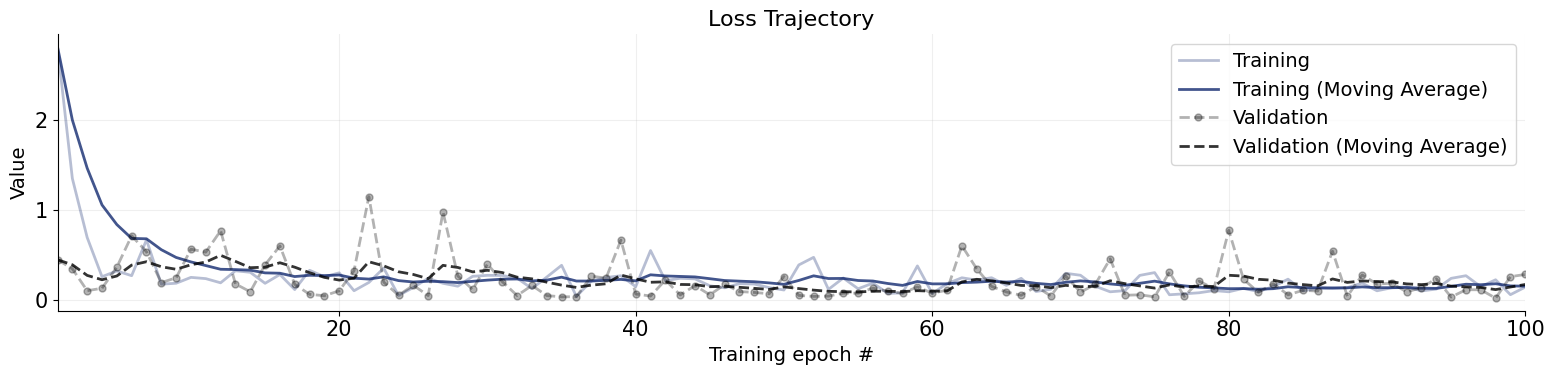

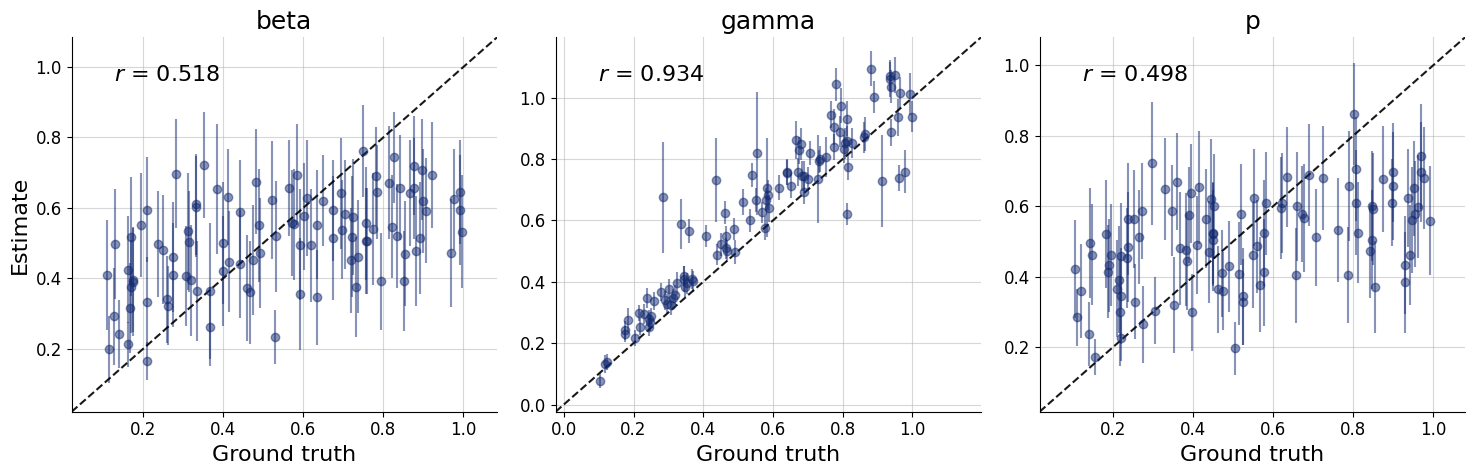

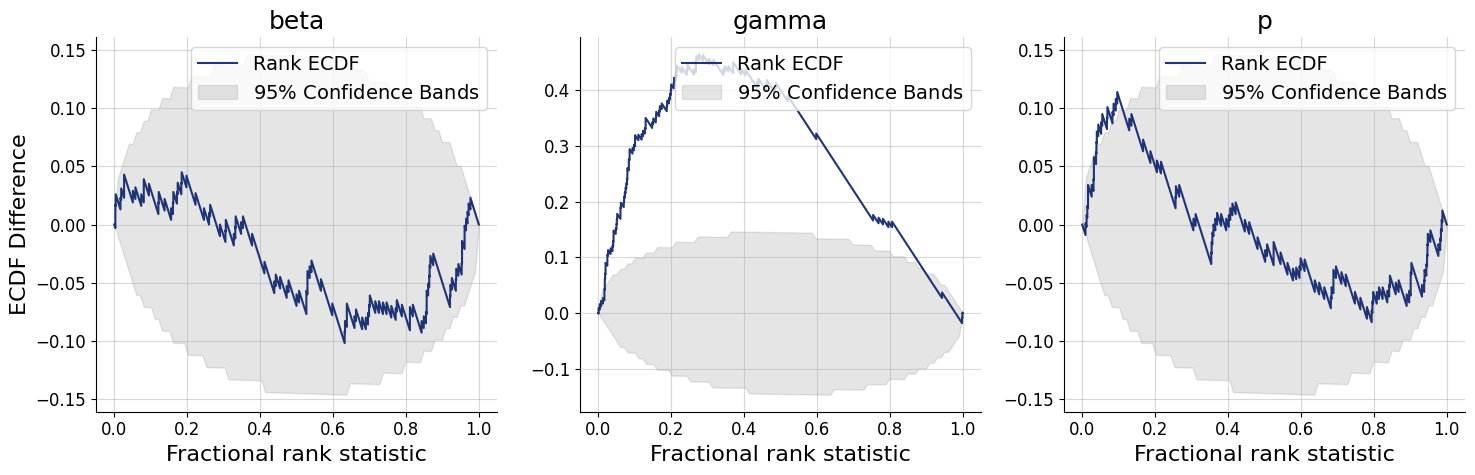

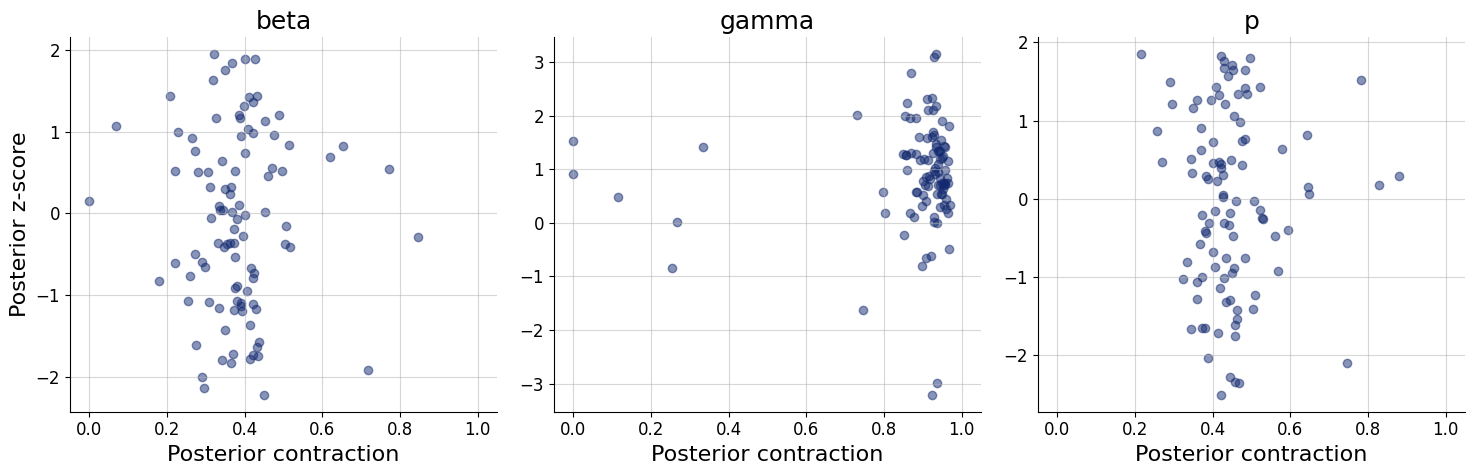

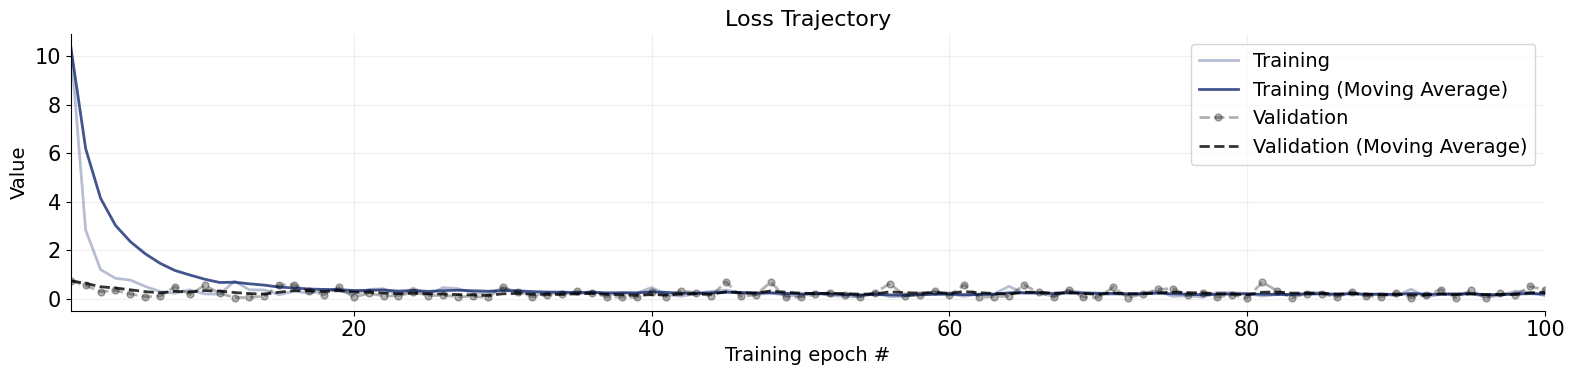

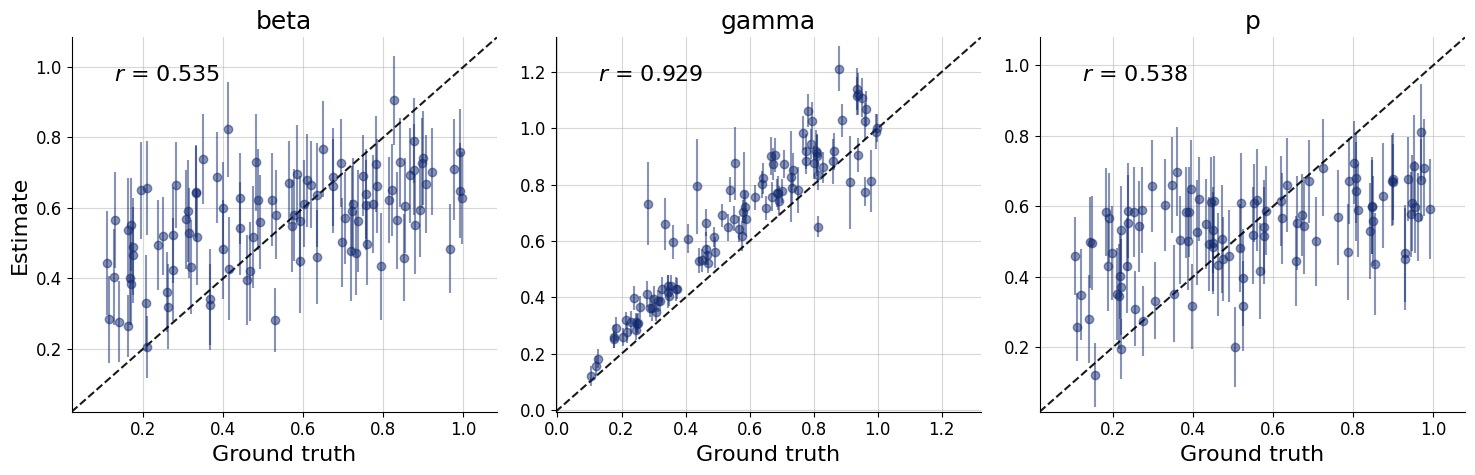

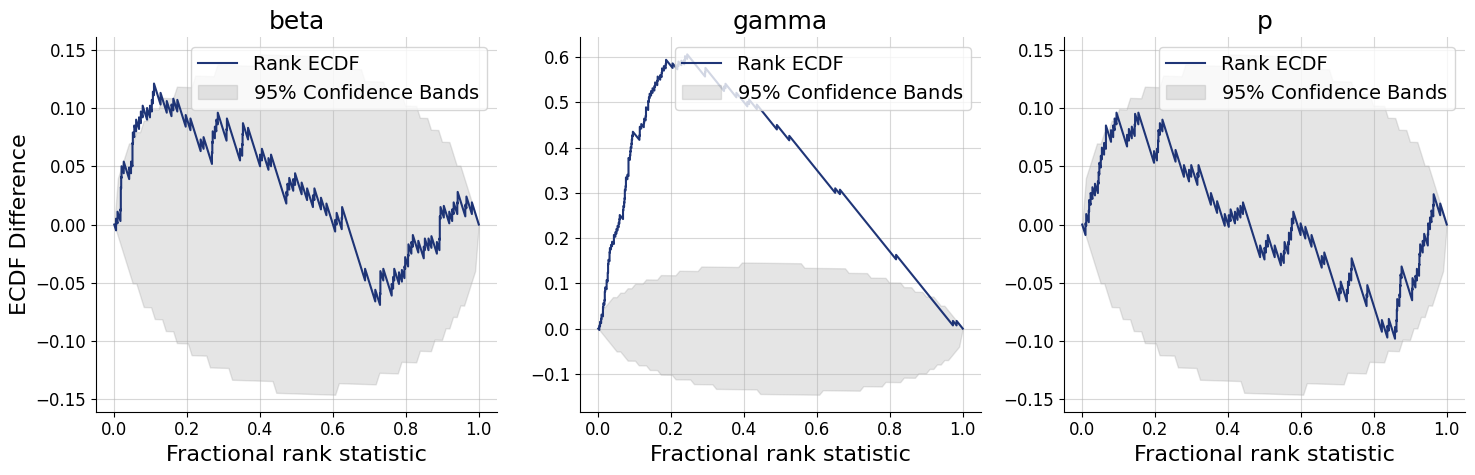

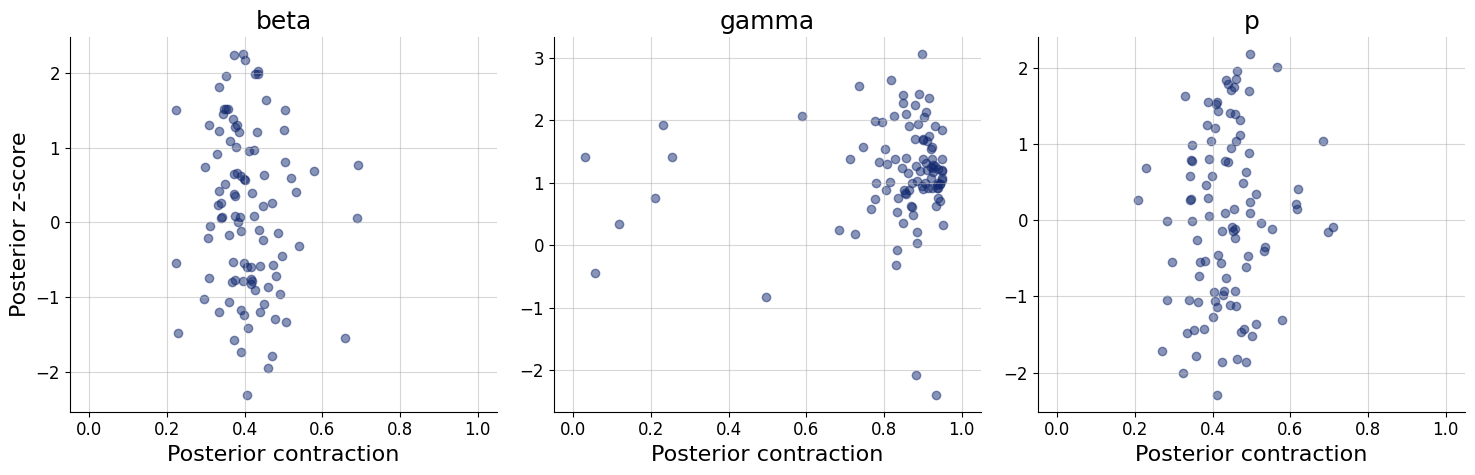

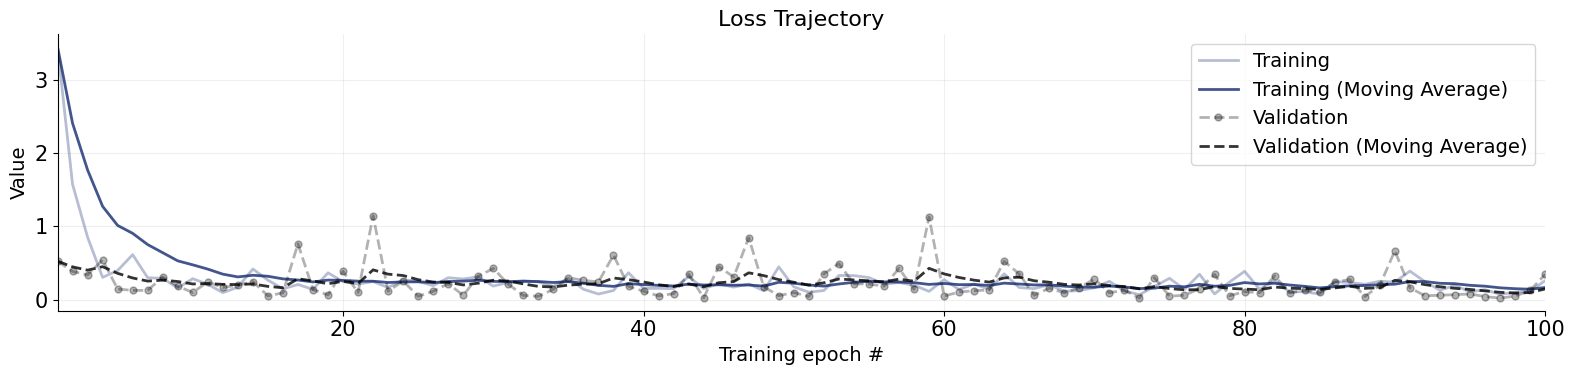

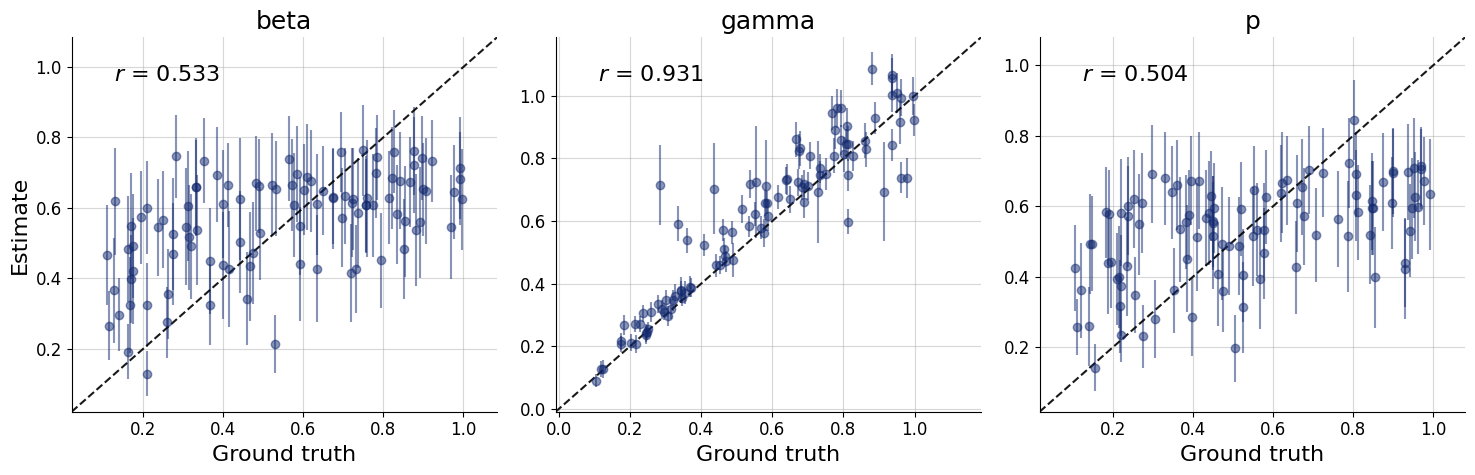

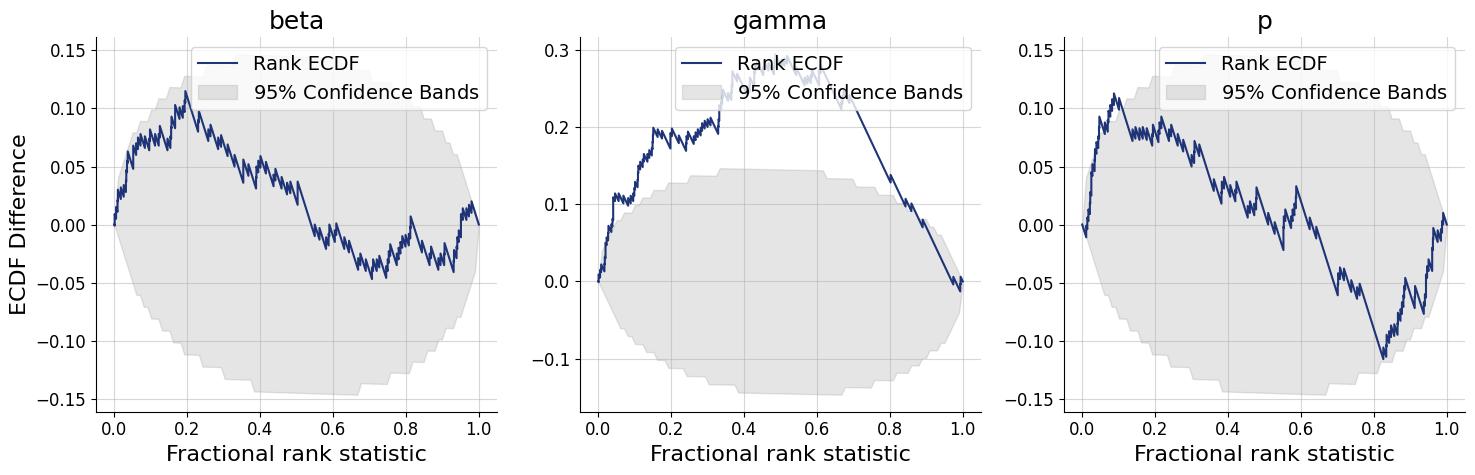

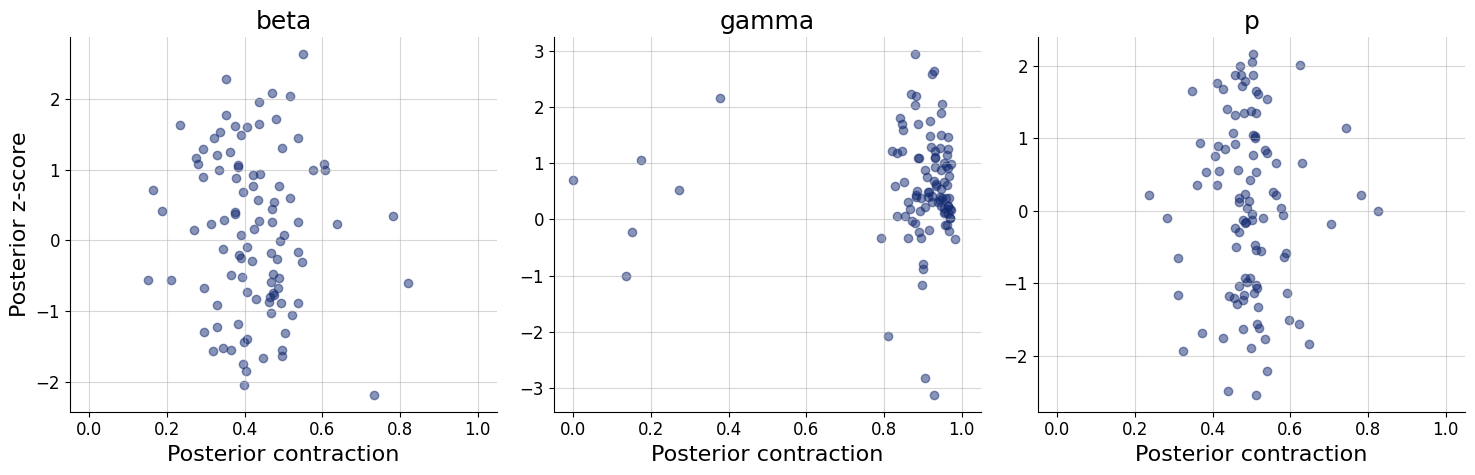

In [43]:
%%time

workflows = {}

for key, train_prior_samples in dict(
    fast_prior=reduced_cost_prior_samples,
    original_prior_less_samples=original_prior_samples_less_samples,
    original_prior=original_prior_samples
).items():

    print(key.upper())

    def simulate_func(samples):
        print(f"Simulating observations for {(next(iter(samples.values()))).shape[0]} parameter sets.")
        t01 = time.time()
        sims = samples | simulate_sir_for_parameter_batch(samples)
        t02 = time.time()
        print(f"Completed simulating in {t02-t01:.1f} seconds.")
        sims["total_time"] = t02-t01

        return sims
        
    train_set = load_or_simulate(
        simulate_func,
        f"train_sims_{key}.pkl",
        train_prior_samples
    )
    print(f"Simulator took {train_set.pop('total_time'):.1f} seconds to generate training data.")

    #print("NOTE: Using reduced simulation budget:", train_set["beta"].shape[0]/5)
    #train_set = {k:v[:int(v.shape[0]/5)] if not isinstance(v, float) else v for k,v in train_set.items()}
    
    workflows[key] = bf.BasicWorkflow(
        inference_network=bf.networks.FlowMatching(subnet_kwargs=dict(dropout=0.1)),
        adapter=adapter,
    )
    t1 = time.time()
    history = workflows[key].fit_offline(data=train_set, validation_data=val_sims, epochs=100, batch_size=16, verbose=2)
    t2 = time.time()
    print(f"Training completed in {t2-t1:.1f} seconds.")
    diagnostics = workflows[key].plot_default_diagnostics(test_data=val_sims, calibration_ecdf_kwargs=dict(difference=True))
    workflows[key].computed_metrics = workflows[key].compute_default_diagnostics(test_data=val_sims)
    print(workflows[key].computed_metrics)
    t3 = time.time()
    print(f"Diagnosis completed in {t3-t2:.1f} seconds.")
    print()

Existing checkpoints can _not_ be restored/loaded using this workflow. Upon refitting, the checkpoints will be overwritten. To load the stored approximator from the checkpoint, use approximator = keras.saving.load_model(...)
 /home/ho/programs/anaconda3/envs/efficient-robustness-abi/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:Skipping variable loading for optimizer 'adam', because it has 1 variables whereas the saved optimizer has 169 variables. 


Loaded trained approximator from ./reference.keras
                           beta     gamma         p
NRMSE                  0.352070  0.134510  0.359494
Posterior Contraction  0.285698  0.938962  0.310873
Calibration Error      0.031579  0.019211  0.043421



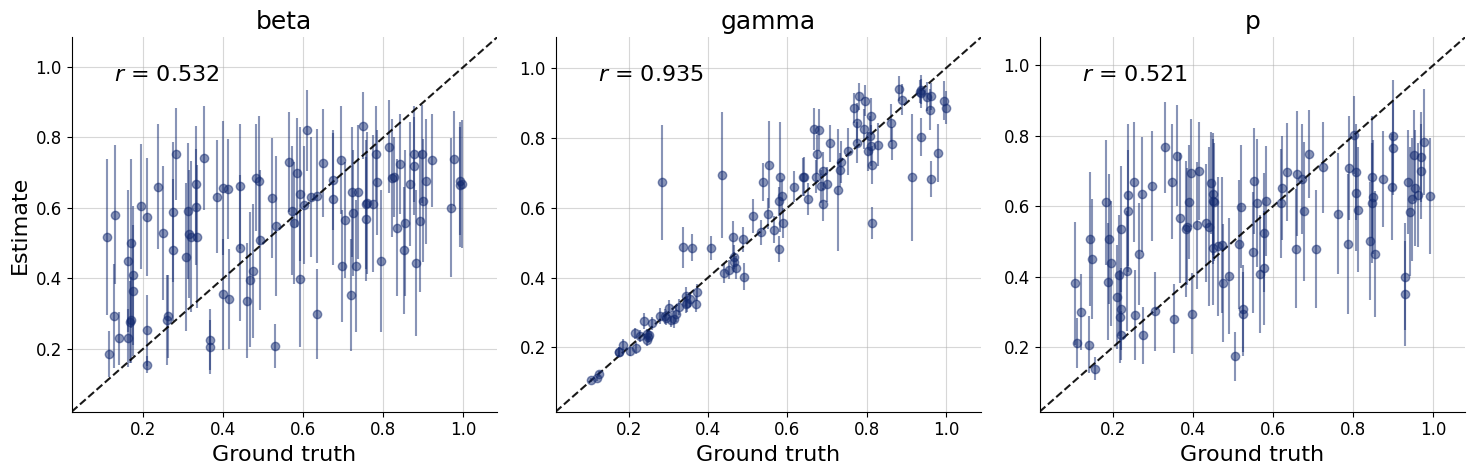

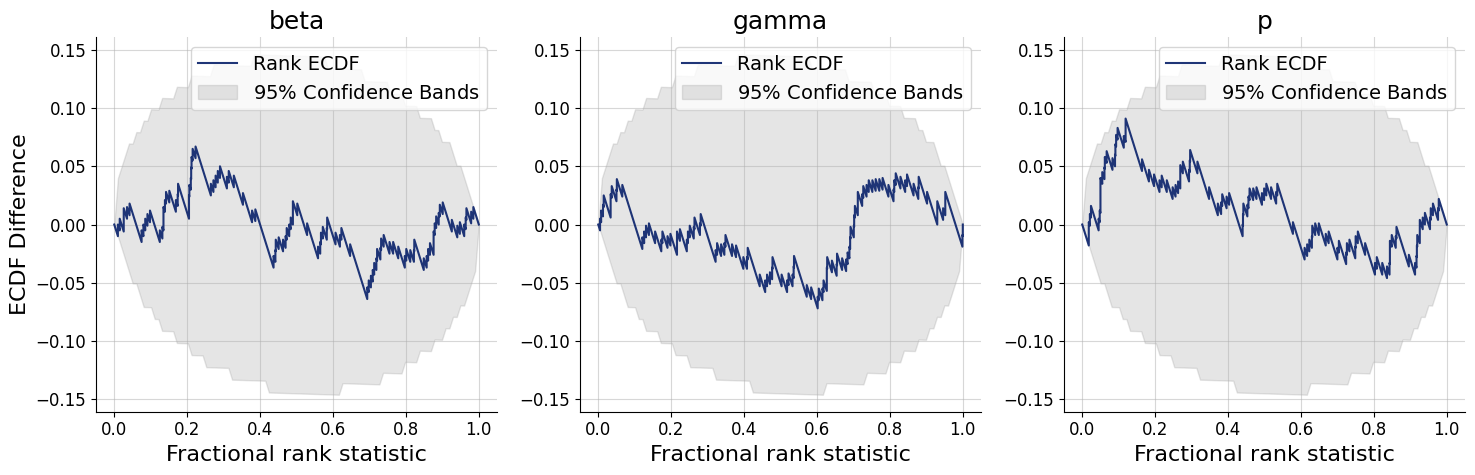

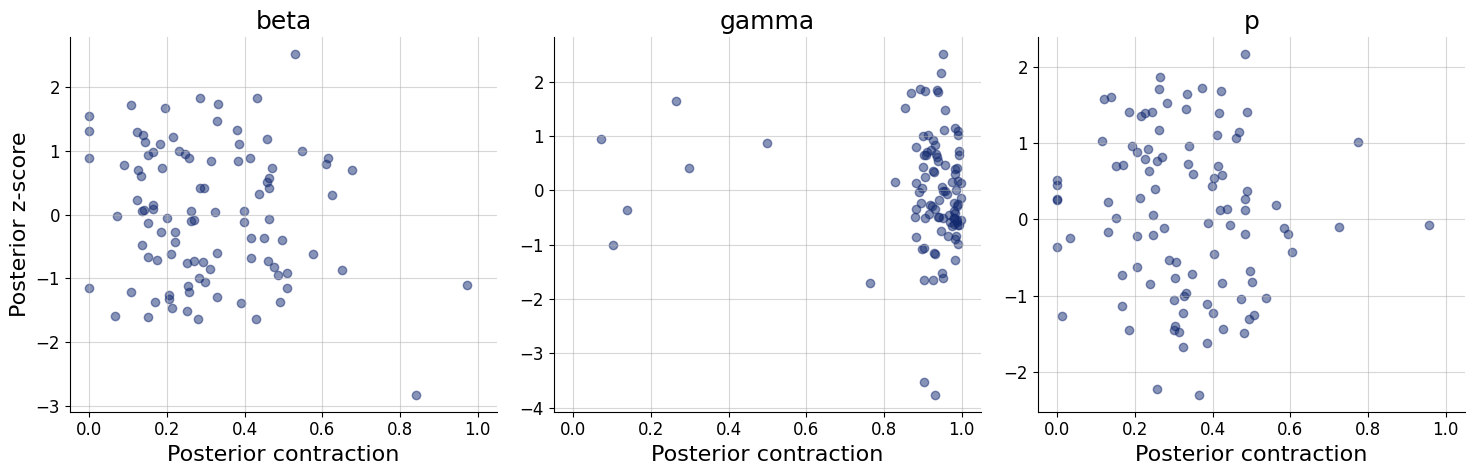

In [44]:
# Reference
checkpoint_filepath = "."
checkpoint_name = "reference"
reference_path = os.path.join(checkpoint_filepath, checkpoint_name+".keras")

reference_workflow = bf.BasicWorkflow(
    inference_network=bf.networks.CouplingFlow(),
    adapter=adapter,
    checkpoint_filepath=checkpoint_filepath,
    checkpoint_name=checkpoint_name,
)

try:
    reference_workflow.approximator = keras.saving.load_model(reference_path)
    print("Loaded trained approximator from", reference_path)
except ValueError:             
    t1 = time.time()
    history = reference_workflow.fit_offline(data=train_sims_large, validation_data=val_sims, epochs=50, batch_size=16, verbose=1)
    t2 = time.time()
    print(f"Training completed in {t2-t1:.1f} seconds.")

diagnostics = reference_workflow.plot_default_diagnostics(test_data=val_sims, calibration_ecdf_kwargs=dict(difference=True))
reference_workflow.computed_metrics = reference_workflow.compute_default_diagnostics(test_data=val_sims)
print(reference_workflow.computed_metrics)
print()

In [45]:
def concat_sample_dict(d):
    return np.concatenate(list(d.values()), axis=-1)

# Comparison of neural posterior approximations for different training sample augmentations

In [47]:
num_test_conditions = 50
test_conditions = {k:v[:num_test_conditions] for k,v in val_sims.items()}

reference_posteriors = reference_workflow.sample(conditions=test_conditions, num_samples=1000)
posteriors = {}
for key, workflow in workflows.items():
    print(key.upper())
    posteriors[key] = workflow.sample(conditions=test_conditions, num_samples=1000)
    mmds = np.ones(num_test_conditions)
    for i in range(num_test_conditions):
        mmds[i] = keras.ops.convert_to_numpy(
            bf.metrics.functional.maximum_mean_discrepancy(concat_sample_dict(reference_posteriors)[i], concat_sample_dict(posteriors[key])[i])
        )
        #print(concat_sample_dict(posteriors[key])[i].max())
        #if concat_sample_dict(posteriors[key])[i].max() > 10000:
            #print(concat_sample_dict(posteriors[key])[i])
        #print(mmds[i])
    print(f"{np.median(mmds):.3f} pm {mmds.std():.3f}")

FAST_PRIOR
0.084 pm 0.051
ORIGINAL_PRIOR_LESS_SAMPLES
0.133 pm 0.083
ORIGINAL_PRIOR
0.060 pm 0.039


In [ ]:
np.any(np.isnan(np.concatenate(list(posteriors["fast_prior"].values()), axis=-1)))

In [ ]:
np.any(np.isnan(np.concatenate(list(reference_posteriors.values()), axis=-1)))

In [ ]:
mmds